# FinPilot AI – Financial Insights

## Objective

This notebook analyzes categorized bank transactions and generates meaningful financial insights such as:

- Monthly spending summary
- Top spending categories
- Income vs Expenses
- Savings suggestions
- AI-powered financial recommendations

This notebook is developed as part of the FinPilot AI project.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from src.categorizer import assign_category
from src.analyzer import calculate_summary, category_summary

df = pd.read_csv("data/transactions_2022_2023.csv")

# Create categories
df["Category"] = df["Name / Description"].apply(assign_category)

# Calculate summary
income, expense, savings = calculate_summary(df)

# Category summary
category_spending = category_summary(df)

df.head()

,Date,Name / Description,Expense/Income,Amount (EUR)
0,2023-12-30,Belastingdienst,Expense,9.96
1,2023-12-30,Tesco Breda,Expense,17.53
2,2023-12-30,Monthly Appartment Rent,Expense,451.00
3,2023-12-30,Vishandel Sier Amsterdam,Expense,12.46
4,2023-12-29,Selling Paintings,Income,13.63


In [3]:
def assign_category(description):
    description = str(description).lower()

    if "tesco" in description:
        return "Groceries"
    elif "rent" in description:
        return "Rent"
    elif "spotify" in description:
        return "Subscription"
    elif "taxi" in description:
        return "Transportation"
    elif "restaurant" in description or "bistro" in description:
        return "Food & Dining"
    elif "consulting" in description:
        return "Salary"
    else:
        return "Miscellaneous"

df["Category"] = df["Name / Description"].apply(assign_category)

df.head()

,Date,Name / Description,Expense/Income,Amount (EUR),Category
0,2023-12-30,Belastingdienst,Expense,9.96,Miscellaneous
1,2023-12-30,Tesco Breda,Expense,17.53,Groceries
2,2023-12-30,Monthly Appartment Rent,Expense,451.00,Rent
3,2023-12-30,Vishandel Sier Amsterdam,Expense,12.46,Miscellaneous
4,2023-12-29,Selling Paintings,Income,13.63,Miscellaneous


In [4]:
# Separate income and expenses
income = df[df["Expense/Income"] == "Income"]["Amount (EUR)"].sum()
expense = df[df["Expense/Income"] == "Expense"]["Amount (EUR)"].sum()

print("Total Income: €", round(income, 2))
print("Total Expense: €", round(expense, 2))
print("Net Savings: €", round(income - expense, 2))

Total Income: € 9665.31
Total Expense: € 851.01
Net Savings: € 8814.3


In [6]:
print(df.columns)

Index(['Date', 'Name / Description', 'Expense/Income', 'Amount (EUR)'], dtype='str')


In [5]:
# Total spending by category

expense_df = df[df["Expense/Income"] == "Expense"]

category_spending = (
    expense_df.groupby("Category")["Amount (EUR)"]
    .sum()
    .sort_values(ascending=False)
)

print(category_spending)

Category
Rent              451.00
Miscellaneous     250.18
Groceries          94.03
Food & Dining      24.71
Transportation     18.90
Subscription       12.19
Name: Amount (EUR), dtype: float64


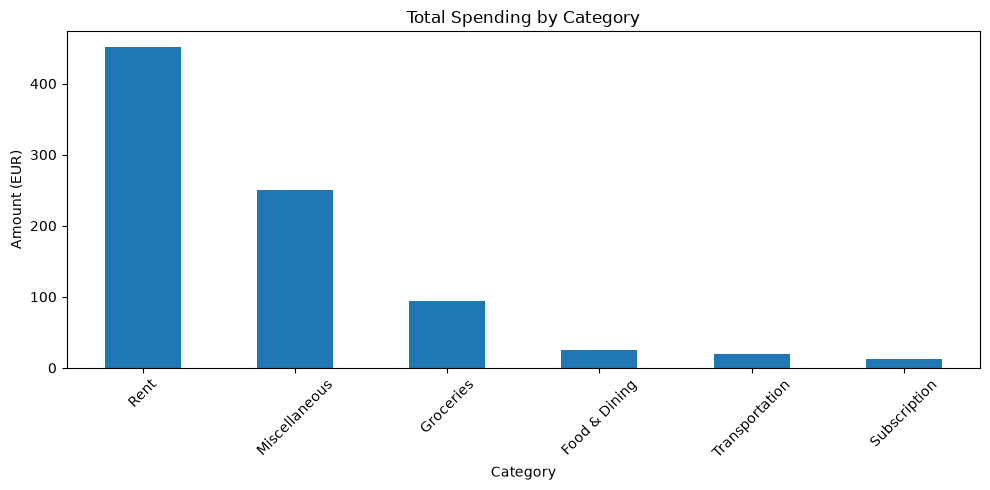

In [9]:
# Bar chart of spending by category

plt.figure(figsize=(10,5))

category_spending.plot(kind="bar")

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (EUR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
# Monthly spending trend

expense_df["Date"] = pd.to_datetime(expense_df["Date"], dayfirst=True)

monthly_expense = (
    expense_df.groupby(expense_df["Date"].dt.to_period("M"))["Amount (EUR)"]
    .sum()
)

print(monthly_expense)

Date
2022-01     65.19
2022-10    110.49
2022-11     82.09
2023-12    593.24
Freq: M, Name: Amount (EUR), dtype: float64


C:\Users\siddh\AppData\Local\Temp\ipykernel_6660\102985232.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  expense_df["Date"] = pd.to_datetime(expense_df["Date"], dayfirst=True)


In [10]:
# Financial Health Score

savings = income - expense

if savings > 5000:
    score = 95
elif savings > 3000:
    score = 85
elif savings > 1000:
    score = 75
else:
    score = 60

print("=" * 40)
print("💰 FinPilot AI Financial Health Report")
print("=" * 40)
print(f"Financial Health Score : {score}/100")
print(f"Total Income           : €{income:.2f}")
print(f"Total Expense          : €{expense:.2f}")
print(f"Net Savings            : €{savings:.2f}")

💰 FinPilot AI Financial Health Report
Financial Health Score : 95/100
Total Income           : €9665.31
Total Expense          : €851.01
Net Savings            : €8814.30


In [11]:
print("\n🤖 AI Financial Recommendations")
print("-" * 40)

# Savings advice
if savings > 5000:
    print("✅ Excellent! You have a strong savings balance.")
else:
    print("⚠️ Try to increase your monthly savings.")

# Spending advice
top_category = category_spending.idxmax()
top_amount = category_spending.max()

print(f"\n📌 Highest Spending Category: {top_category} (€{top_amount:.2f})")

if top_category == "Food & Dining":
    print("💡 Consider reducing restaurant spending.")
elif top_category == "Shopping":
    print("💡 Try setting a monthly shopping budget.")
elif top_category == "Subscription":
    print("💡 Review unused subscriptions.")
elif top_category == "Transportation":
    print("💡 Consider using public transport when possible.")
elif top_category == "Rent":
    print("💡 Rent is your biggest expense. Plan the rest of your budget carefully.")
else:
    print("💡 Continue monitoring your spending habits.")


🤖 AI Financial Recommendations
----------------------------------------
✅ Excellent! You have a strong savings balance.

📌 Highest Spending Category: Rent (€451.00)
💡 Rent is your biggest expense. Plan the rest of your budget carefully.


In [12]:
# Save categorized transactions

df.to_csv("categorized_transactions.csv", index=False)

print("✅ Categorized transactions saved successfully!")

✅ Categorized transactions saved successfully!


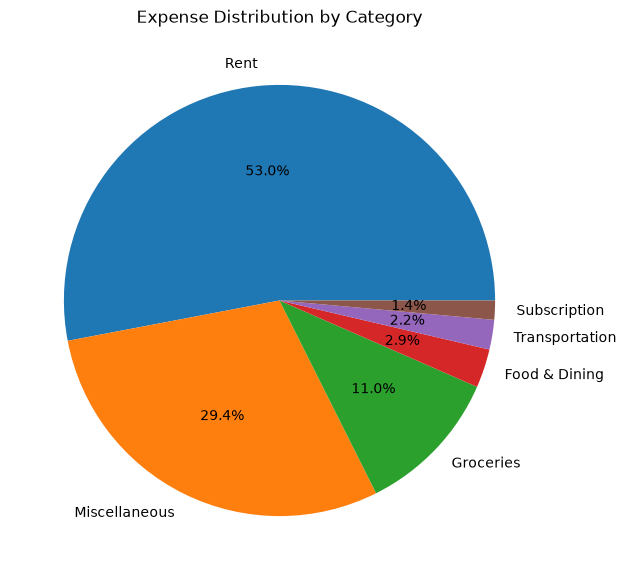

In [7]:
# Expense Distribution Pie Chart

plt.figure(figsize=(7,7))

category_spending.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Expense Distribution by Category")
plt.ylabel("")

plt.show()